In [15]:
import os
import rosalia as rs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [32]:
roman_mu_all_filters

array([22.34280314, 22.23201844, 22.32669107, 22.4983046 , 22.6326748 ,
       22.76226325, 22.58108868, 22.89892768])

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [16]:
# In this notebook we will measure the surface brightness limit for Roman Space Telescope mosaics. 
# This is a very approximate solution that does not take into account systematic effects like 
# flat field, CTE, bias, or gradients. The only limiting factor is photon noise from Zodiacal light
# However, Zodiacal light is 95% of the limit, so it will work sufficiently well for most purposes.
# For a more realistic simulation, see Romanisim: https://romanisim.readthedocs.io/en/latest/
# Use this notebook at your own risk. 

In [17]:
for filter_name in rs.roman.rosalia_bandpasses_names:
    filter_db = rs.telescopes.find_filter_in_svo(wavelength=filter_name,
                                                 telescope="Roman",
                                                 instrument="WFI",
                                                 detector="WFI",
                                                 verbose=False)

    

In [19]:
telescope="Roman"
instrument="WFI"
filter_name = "F129"
exptime=600

mu_sky = 22.5 # mag / arcsec2 - This is the approximate surface brightness of the Zodiacal light

maglim = rs.utils.measure_maglim(mu_sky, instrument, filter_name, telescope, exptime, verbose=False)
print(maglim)

[29.26821201]


In [21]:
# F062	F087	F106	F129	F158	F184	F213	F146
# 0.27	0.27	0.29	0.28	0.26	0.15	0.13	0.85
# Internal thermal backgrounds (count rate per pixel)
# F062	F087	F106	F129	F158	F184	F213	F146
# 0	0	0	0	0.04	0.17	4.52	0.98
roman_band = pd.read_csv(os.environ["ROSALIACACHE"] + "CORE/Roman_effarea_20210614.csv",comment="#") 

roman_zody = np.array([0.27,0.27,0.29,0.28,0.26,0.15,0.85,0.13])
roman_thermal=np.array([0,0,0,0,0.04,0.17,0.98,4.52])


F062_dl = 0.760-0.480
F087_dl = 0.977-0.760
F106_dl = 1.192-0.927
F129_dl = 1.454-1.131
F158_dl = 1.774 - 1.380
F184_dl = 2.000-1.683
F213_dl = 2.300-1.950
F146_dl = 2.000-0.927

roman_bandpass = np.array([F062_dl,F087_dl,F106_dl,F129_dl,F158_dl,F184_dl,F146_dl,F213_dl])


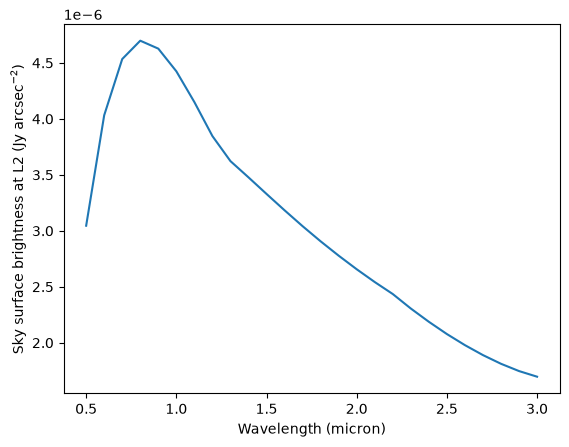

[22.34280314 22.23201844 22.32669107 22.4983046  22.6326748  22.76226325
 22.58108868 22.89892768]
[22.37144464 22.26810739 22.37047296 22.55458739 22.70447433 22.84927281
 22.6469029  23.00235044]
[        inf         inf         inf         inf 24.73653024 22.71304125
 22.49212774 19.14912428]
[27.33467636 26.75970012 26.45940624 26.20600126 26.02262028 25.92033042
 26.08142931 25.85984159]
[26.83695423 26.64436474 26.73806147 26.88343562 26.88574823 26.88574823
 26.88574823 26.88574823]


ValueError: operands could not be broadcast together with shapes (26,) (8,) 

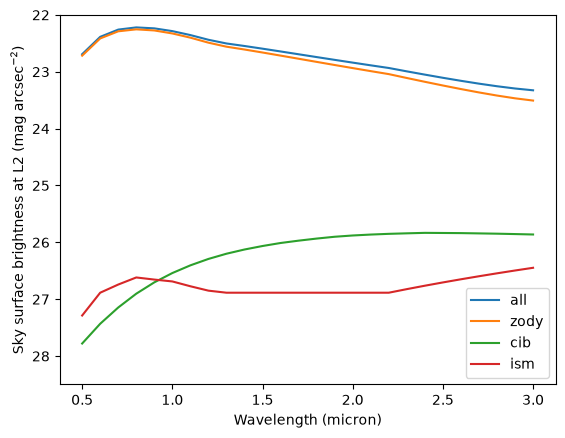

In [37]:
# Mu sky per filter. 
# Read HST background file
roman_sky_db = pd.read_csv(os.environ["ROSALIACACHE"] + "CORE/roman_background.csv",comment="#") 
roman_sky =  np.array(roman_sky_db["zody"]+ roman_sky_db["ism"]+ roman_sky_db["cib"]) *10**6/(4.25*10**10) 
roman_wave = roman_sky_db["wavelength"]
plt.plot(roman_wave, roman_sky)
plt.xlabel("Wavelength (micron)")
plt.ylabel("Sky surface brightness at L2 (Jy arcsec$^{-2}$)")
plt.savefig("L2_sky_vs_wave.png", dpi=300)
plt.show()

roman_mu_all = -2.5*np.log10(roman_sky)+8.9
roman_mu_zody = -2.5*np.log10(np.array(roman_sky_db["zody"])*10**6/(4.25*10**10))+8.9
roman_mu_cib = -2.5*np.log10(np.array(roman_sky_db["cib"])*10**6/(4.25*10**10))+8.9
roman_mu_ism = -2.5*np.log10(np.array(roman_sky_db["ism"])*10**6/(4.25*10**10))+8.9

roman_zody_int_filter = np.interp(x=filter_wave, xp=roman_wave, fp=np.array(roman_sky_db["zody"])*10**6/(4.25*10**10)) # Jy/arcsec²
roman_thermal_int_filter = roman_zody_int_filter*roman_thermal/roman_zody

plt.plot(roman_wave, roman_mu_all, label="all")
plt.plot(roman_wave, roman_mu_zody, label="zody")
#plt.plot(roman_wave, roman_mu_thermal, color="red")
plt.plot(roman_wave, roman_mu_cib, label="cib")
plt.plot(roman_wave, roman_mu_ism, label="ism")
plt.xlabel("Wavelength (micron)")
plt.ylabel("Sky surface brightness at L2 (mag arcsec$^{-2}$)")
plt.ylim((28.5,22))
plt.legend()
plt.savefig("L2_sky_vs_wave_mag.png", dpi=300)

roman_mu_all_filters = np.interp(x=filter_wave, xp=roman_wave, fp=roman_mu_all) 
roman_mu_zody_filters = np.interp(x=filter_wave, xp=roman_wave, fp=roman_mu_zody) 
roman_mu_thermal_filters = -2.5*np.log10(roman_thermal_int_filter) + 8.9
roman_mu_cib_filters = np.interp(x=filter_wave, xp=roman_wave, fp=roman_mu_cib) 
roman_mu_ism_filters = np.interp(x=filter_wave, xp=roman_wave, fp=roman_mu_ism) 
print(roman_mu_all_filters)
print(roman_mu_zody_filters)
print(roman_mu_thermal_filters)
print(roman_mu_cib_filters)
print(roman_mu_ism_filters)

roman_mu_all_plus_thermal = -2.5*np.log10(roman_sky+roman_thermal_int_filter)+8.9

In [38]:
roman_sky

array([3.04541176e-06, 4.03225882e-06, 4.53447059e-06, 4.69835294e-06,
       4.62738824e-06, 4.42498824e-06, 4.14990588e-06, 3.84628235e-06,
       3.62254118e-06, 3.47743529e-06, 3.32929412e-06, 3.18315294e-06,
       3.04122353e-06, 2.90590588e-06, 2.77781176e-06, 2.65644706e-06,
       2.54216471e-06, 2.43505882e-06, 2.30560000e-06, 2.18710588e-06,
       2.07757647e-06, 1.97844706e-06, 1.88948235e-06, 1.81190588e-06,
       1.74682353e-06, 1.69656471e-06])

[29.31819666]
[29.09659483]
[29.17352857]
[29.26736431]
[29.35181032]
[29.19055083]
[29.92397589]
[29.23752609]


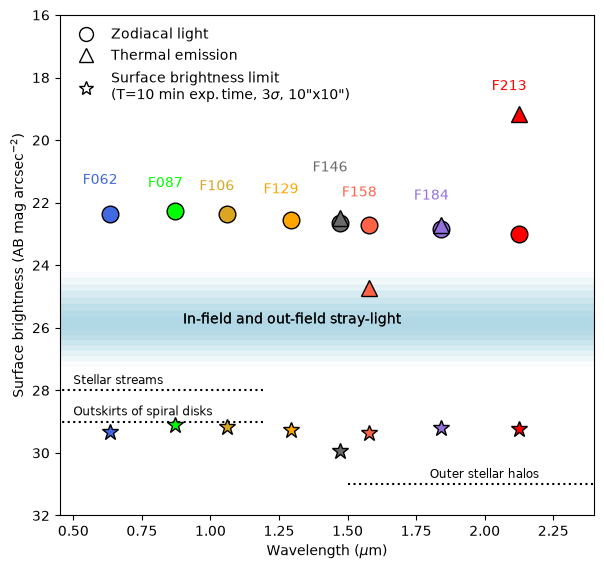

In [35]:
fig, ax = plt.subplots(figsize=(6.9,6.5))

filter_wave = []
max_apperture = []

colors = ["royalblue", "lime", "goldenrod", "orange", "tomato", "mediumpurple","dimgrey", "red"]

roman_wfi_filters = ["F062", "F087", "F106", "F129", "F158", "F184", "F146", "F213"]
for id, i, color, ytext in zip(range(8), roman_wfi_filters,
                    colors,
                    np.array([21.4, 21.5, 21.6, 21.7, 21.8, 21.9, 21.0, 18.4])):
    #ax.plot(roman_band["Wave"], roman_band[i], color=color, linestyle="--",
    #        linewidth=2, label=i)
    #ax.scatter(profile["R"]*pixsize_hawc, profile["pitch"], color=color, marker=marker,
    #           label='')
    # Error bars
    #ax.fill_between(roman_band["Wave"], roman_band[i],  roman_band[i]*0,
    #                where=(roman_band[i]> roman_band[i]*0), facecolor=color,
    #                alpha=0.2, label="")
    filter_ref_wave = np.sum(roman_band["Wave"]*roman_band[i])/np.sum(roman_band[i])
    plt.text(x=filter_ref_wave - 0.1,
             y=ytext, s=i, color=color)
    max_apperture.append(np.max(roman_band[i]))
    filter_wave.append(filter_ref_wave)


max_apperture = np.array(max_apperture)
filter_wave = np.array(filter_wave)

# Zodiacal light
ax.plot(0, 0,  marker="o", markerfacecolor="white", fillstyle="full",
             markersize=10, markeredgecolor="black", linewidth=0, label="Zodiacal light")

# Thermal emission
ax.plot(0, 0, marker="^", markerfacecolor="white", fillstyle="full",
             markersize=10, markeredgecolor="black", linewidth=0, label="Thermal emission")

# Stray-light level
# μstray = 25.86+0.30−0.37

n_shadows = 10
for n,alpha in zip(np.linspace(0,5,n_shadows),np.linspace(0.5,0.001,n_shadows)):
    stray_euclid = 25.86
    stray_up_euclid_1s = 25.86 + 0.30*n
    stray_down_euclid_1s = 25.86 - 0.37*n

    ax.fill_between(x=[0,3], y1=[stray_up_euclid_1s, stray_up_euclid_1s], 
                    y2=[stray_down_euclid_1s, stray_down_euclid_1s], alpha=alpha, color="lightblue")

plt.text(x=0.9, y=stray_euclid, s="In-field and out-field stray-light", color="black")
ax.plot(0, 0, marker="*", markerfacecolor="white", fillstyle="full",
             markersize=10, markeredgecolor="black", linewidth=0, label='Surface brightness limit \n(T=10 min exp.$\,$time, 3$\sigma$, 10"x10")')


plt.text(x=0.9, y=stray_euclid, s="In-field and out-field stray-light", color="black")

plt.text(x=0.5, y=27.8, s="Stellar streams", color="black", fontsize="small")
plt.plot([0.3, 1.2], [28,28], linestyle=":", linewidth=1.5, color="black")

plt.text(x=0.5, y=28.8, s="Outskirts of spiral disks", color="black", fontsize="small")
plt.plot([0.3, 1.2], [29,29], linestyle=":", linewidth=1.5, color="black")

plt.text(x=1.8, y=30.8, s="Outer stellar halos", color="black", fontsize="small")
plt.plot([1.5, 3.2], [31,31], linestyle=":", linewidth=1.5, color="black")


for i in range(len(colors)):

    # Magnitude limit for 10 min exposure, 3 sigma, 10"x10" area
    maglim = rs.utils.measure_maglim(mu_sky=roman_mu_all_filters[i], instrument="WFI", filter_name=roman_wfi_filters[i], telescope="Roman", exptime=exptime, verbose=False)
    print(maglim)

    ax.plot(filter_wave[i], roman_mu_zody_filters[i],  marker="o", markerfacecolor=colors[i], fillstyle="full",
             markersize=12, markeredgecolor="black", linewidth=0)
    ax.plot(filter_wave[i], roman_mu_thermal_filters[i], marker="^", markerfacecolor=colors[i], fillstyle="full",
             markersize=12, markeredgecolor="black", linewidth=0)
    ax.plot(filter_wave[i], maglim, marker="*", markerfacecolor=colors[i], fillstyle="full",
             markersize=12, markeredgecolor="black", linewidth=0)
    
    
plt.xlim(0.45,2.4)
ax.set_ylim(32,16)
ax.set_xlabel(r'Wavelength ($\mu$m)')
ax.set_ylabel(r'Surface brightness (AB mag arcsec$^{-2}$)')
plt.legend(loc='upper left', frameon=False, ncol=1)
plt.savefig("roman_filter.png", dpi=300)